# Configurações iniciais e pacotes importados



In [15]:
import numba
from numba import njit
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm, rayleigh

# Configuracao das figuras
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["font.size"] = 12
mpl.rcParams["axes.linewidth"] = 1.2

# Para criar ama representação do caixa (onde seram introduzidas as partículas)
from matplotlib import animation
from matplotlib.patches import Circle, Rectangle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [3]:
params = {
    "N": 200,
    "L": 30,
    "dt": 0.002,
    "m": 1.0,
    "epsilon": 1.0,
    "sigma": 1.0,
    "r_cut": 2.5,
    "velocity_distribution": "uniform",
    "v0": 2.0,
    "n_steps": 10000
}

# Funções a serem utilizadas

In [4]:
def initialize_positions_LJ(N, L, sigma, min_dist_factor=0.9):
    """
    Initialize particle positions randomly inside a box [0, L] x [0, L],
    ensuring a minimum separation to avoid huge LJ forces.

    min_dist_factor ~ 0.9 to 1.0 is safe.
    """
    pos = np.zeros((N, 2))
    min_dist = min_dist_factor * sigma

    for i in range(N):
        while True:
            candidate = np.random.uniform(0, L, size=2)

            if i == 0:
                pos[i] = candidate
                break

            dist = np.linalg.norm(pos[:i] - candidate, axis=1)

            if np.all(dist > min_dist):
                pos[i] = candidate
                break

    return pos

In [5]:
# Inicializa as velocidades das partículas de acordo com a distribuição especificada
# Existe a opção de distribuição de velocidades "maxwell", "uniform" ou "fixed"
# maxwell: velocidades seguem uma distribuição normal com média 0 e desvio padrão v0
# uniform: velocidades são uniformemente distribuídas entre -v0 e v0
# fixed: todas as partículas têm a mesma velocidade v0, mas direções aleatórias
def initialize_velocities(N, distribution="maxwell", v0=1.0, m=1.0):
    """
    Initialize velocities and remove center-of-mass motion.
    """
    if distribution == "maxwell":
        vel = np.random.normal(0, v0, size=(N, 2))

    elif distribution == "uniform":
        vel = np.random.uniform(-v0, v0, size=(N, 2))

    elif distribution == "fixed":
        angles = np.random.uniform(0, 2 * np.pi, N)
        vel = v0 * np.column_stack((np.cos(angles),
                                    np.sin(angles)))
    else:
        raise ValueError("Distribuição de velocidades desconhecida")

    # Remove center-of-mass velocity
    vel -= np.mean(vel, axis=0)

    return vel

In [6]:
@njit
def compute_forces(x, y, L, epsilon, sigma, r_cut):
    N = len(x)
    Fx = np.zeros(N)
    Fy = np.zeros(N)
    U = 0.0

    r_cut2 = r_cut**2
    sig2 = sigma**2
    sig6 = sig2**3
    sig12 = sig6**2
    
    # Pre-calculate the potential energy shift to avoid discontinuities at r_cut
    # U_shift = 4 * epsilon * ((sigma/r_cut)**12 - (sigma/r_cut)**6)

    for i in range(N - 1):
        for j in range(i + 1, N):
            dx = x[i] - x[j]
            dy = y[i] - y[j]
            
            # If using Periodic Boundary Conditions (uncomment if needed):
            # dx -= L * round(dx / L)
            # dy -= L * round(dy / L)
            
            r2 = dx*dx + dy*dy

            if r2 < r_cut2:
                inv_r2 = 1.0 / r2
                inv_r6 = sig6 * (inv_r2**3)
                inv_r12 = sig12 * (inv_r2**6)

                # Lennard-Jones Force: F = -dU/dr
                # force_scalar = 48 * epsilon * (inv_r12 - 0.5 * inv_r6) * inv_r2
                force_scalar = 24 * epsilon * (2 * inv_r12 - inv_r6) * inv_r2

                fx = force_scalar * dx
                fy = force_scalar * dy

                Fx[i] += fx
                Fy[i] += fy
                Fx[j] -= fx
                Fy[j] -= fy

                # Potential energy
                U += 4 * epsilon * (inv_r12 - inv_r6)

    return Fx, Fy, U



In [7]:
def velocity_verlet_step(x, y, vx, vy, Fx, Fy, m, dt,
                         L, epsilon, sigma, r_cut):

    # Half velocity update
    vx += 0.5 * Fx / m * dt
    vy += 0.5 * Fy / m * dt

    # Position update
    x += vx * dt
    y += vy * dt

    # Apply walls
    apply_reflective_walls(x, y, vx, vy, L)

    # Compute new forces
    Fx_new, Fy_new, U = compute_forces(x, y, L, epsilon, sigma, r_cut)

    # Complete velocity update
    vx += 0.5 * Fx_new / m * dt
    vy += 0.5 * Fy_new / m * dt

    return x, y, vx, vy, Fx_new, Fy_new, U

In [8]:
def animate_simulation_recorded(pos_traj, params, interval=20):
    """
    Animates a simulation from pre-recorded trajectory data.
    pos_traj shape: (n_steps, N, 2)
    """
    L = params["L"]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_aspect("equal")
    
    # Initialize scatter plot
    scat = ax.scatter(pos_traj[0, :, 0], pos_traj[0, :, 1], s=5)

    def update(frame):
        # Simply pull the frame from the trajectory vector
        scat.set_offsets(pos_traj[frame])
        return scat,

    anim = FuncAnimation(
        fig,
        update,
        frames=len(pos_traj),
        interval=interval,
        blit=True
    )

    plt.close(fig) # Prevents an extra static plot from appearing
    return anim

In [9]:
def rescale_to_temperature(vel, T_target, m=1.0):
    """
    Rescale velocities to match target temperature.
    """
    N = len(vel)
    K = 0.5 * m * np.sum(vel**2)
    T_current = K / N  # 2D equipartition

    scale = np.sqrt(T_target / T_current)
    vel *= scale

    return vel

# Dinâmica: Adicionando tempo à simulação

In [10]:
def step(pos, vel, forces, params):
    dt = params["dt"]
    m = params["m"]
    L = params["L"]
    eps = params["epsilon"]
    sigma = params["sigma"]
    r_cut = params["r_cut"]

    # 1. Update velocities (half step)
    vel += 0.5 * (forces / m) * dt
    
    # 2. Update positions
    pos += vel * dt
    
    # 3. Boundary conditions (Reflective Walls)
    # X boundaries
    mask_x_low = pos[:, 0] < 0
    pos[mask_x_low, 0] = -pos[mask_x_low, 0]
    vel[mask_x_low, 0] *= -1
    
    mask_x_high = pos[:, 0] > L
    pos[mask_x_high, 0] = 2*L - pos[mask_x_high, 0]
    vel[mask_x_high, 0] *= -1
    
    # Y boundaries
    mask_y_low = pos[:, 1] < 0
    pos[mask_y_low, 1] = -pos[mask_y_low, 1]
    vel[mask_y_low, 1] *= -1
    
    mask_y_high = pos[:, 1] > L
    pos[mask_y_high, 1] = 2*L - pos[mask_y_high, 1]
    vel[mask_y_high, 1] *= -1

    # 4. Compute new forces
    Fx, Fy, U = compute_forces(pos[:, 0], pos[:, 1], L, eps, sigma, r_cut)
    new_forces = np.column_stack((Fx, Fy))

    # 5. Update velocities (final half step)
    vel += 0.5 * (new_forces / m) * dt

    return pos, vel, new_forces, U

In [11]:
def run_simulation(params):

    # --- Initialization ---
    pos = initialize_positions_LJ(
        params["N"],
        params["L"],
        params["sigma"]
    )

    vel = initialize_velocities(
        params["N"],
        params["velocity_distribution"],
        params["v0"],
        m=params["m"]
    )

    # Initial forces
    Fx, Fy, U = compute_forces(
        pos[:, 0], pos[:, 1],
        params["L"],
        params["epsilon"],
        params["sigma"],
        params["r_cut"]
    )

    forces = np.column_stack((Fx, Fy))

    energies = []

    # --- Time evolution ---
    for _ in range(params["n_steps"]):

        pos, vel, forces, U = step(pos, vel, forces, params)

        K = 0.5 * params["m"] * np.sum(vel**2)
        energies.append(K + U)

    return pos, vel, np.array(energies)

In [12]:
def run_simulation_recorded(params):
    """
    Runs the MD simulation and returns the full trajectory of 
    positions, velocities, and total energy over time.
    """
    # Initialize system based on params
    pos = initialize_positions_LJ(
        params["N"], 
        params["L"], 
        params["sigma"]
    )
    
    vel = initialize_velocities(
        params["N"], 
        params["velocity_distribution"], 
        params["v0"], 
        m=params["m"]
    )

    # Pre-allocate trajectory arrays: (Steps, Particles, Dimensions)
    n_steps = params["n_steps"]
    N = params["N"]
    
    pos_traj = np.zeros((n_steps, N, 2))
    vel_traj = np.zeros((n_steps, N, 2))
    energies = np.zeros(n_steps)

    # Initial force calculation
    Fx, Fy, U = compute_forces(
        pos[:, 0], pos[:, 1], 
        params["L"], 
        params["epsilon"], 
        params["sigma"], 
        params["r_cut"]
    )
    forces = np.column_stack((Fx, Fy))

    # Time evolution loop
    for i in range(n_steps):
        # Update system using the Velocity-Verlet step
        pos, vel, forces, U = step(pos, vel, forces, params)
        
        # Store current state in the trajectory vectors
        pos_traj[i] = pos.copy()
        vel_traj[i] = vel.copy()
        
        # Calculate total energy (Kinetic + Potential)
        K = 0.5 * params["m"] * np.sum(vel**2)
        energies[i] = K + U

    return pos_traj, vel_traj, energies

# Testes

Testes para melhor compreensão e debug do código.

Text(0, 0.5, 'Total Energy')

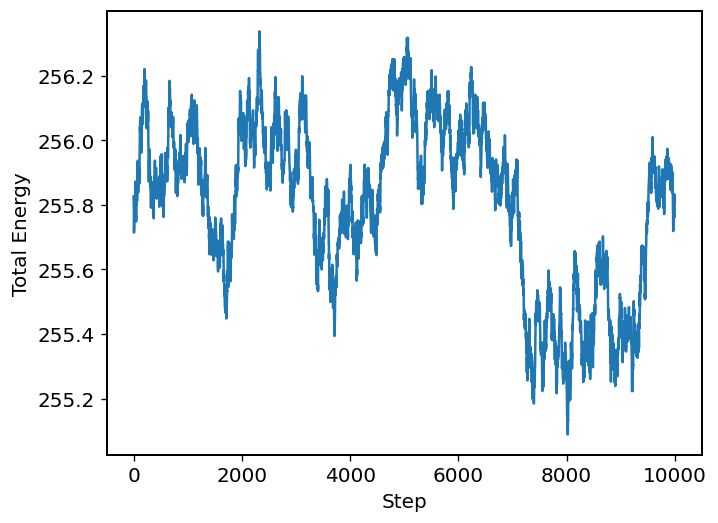

In [13]:

pos, vel, energies = run_simulation(params)


plt.plot(energies)
plt.xlabel("Step")
plt.ylabel("Total Energy")

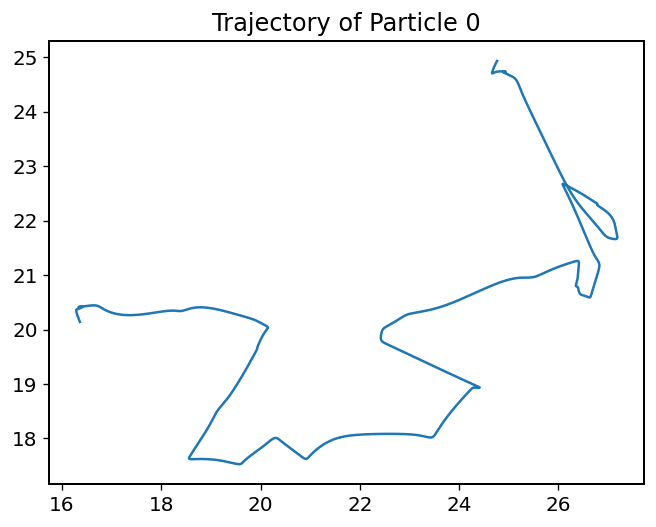

200


Text(0, 0.5, 'Temperature')

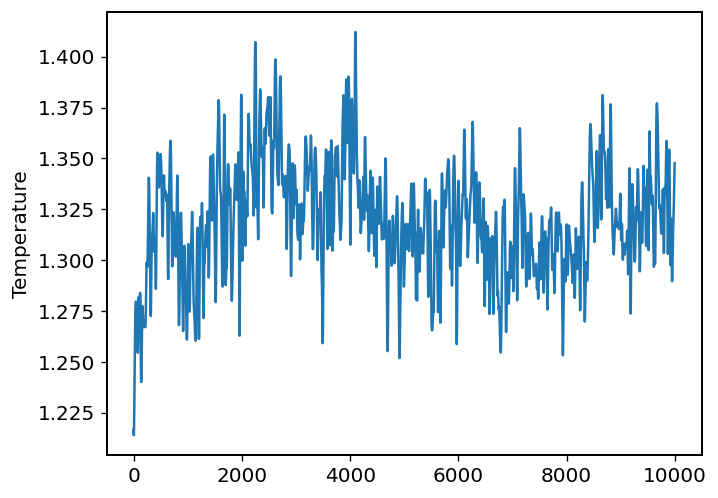

In [14]:

pos_traj, vel_traj, energies = run_simulation_recorded(params)


# Extract X and Y for particle 0 over all time steps
plt.plot(pos_traj[:, 0, 0], pos_traj[:, 0, 1])
plt.title("Trajectory of Particle 0")
plt.show()

N = params["N"]
print(N)

# Sum velocities squared for all particles (axis 1 and 2) at each time step
kinetic_energies = 0.5 * params["m"] * np.sum(vel_traj**2, axis=(1, 2))
temperatures = kinetic_energies / N # Assuming kB = 1
plt.plot(temperatures)
plt.ylabel("Temperature")

Text(0.5, 1.0, 'Path of Particle 1')

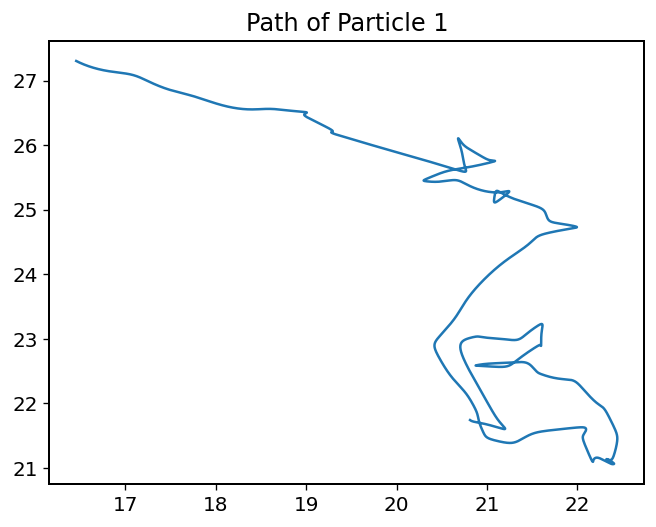

In [15]:
# Plot the path of the first particle
plt.plot(pos_traj[:, 1, 0], pos_traj[:, 1, 1])
plt.title("Path of Particle 1")


In [16]:
# 1. Run the simulation once and store the data
pos_traj, vel_traj, energies = run_simulation_recorded(params)

# 2. Pass the data to the animator
anim = animate_simulation_recorded(pos_traj, params)

anim.save("gas_simulation_lj.mp4", fps=30)

# Resultados - Observáveis físicos

In [13]:
def analyze_observables(params, n_avg_steps=5000):
    """
    Realiza a simulação, extrai dados de equilíbrio e faz o ajuste (fit) 
    estatístico das distribuições de velocidade.
    """
    # 1. Rodar simulação e obter trajetórias
    # Usamos a versão gravada para ter uma amostragem estatística melhor
    _, v_traj, _ = run_simulation_recorded(params)
    
    # Pegar os últimos passos (onde o sistema já deve estar em equilíbrio)
    v_sample = v_traj[-n_avg_steps:]
    vx = v_sample[:, :, 0].flatten()
    vy = v_sample[:, :, 1].flatten()
    speed = np.sqrt(vx**2 + vy**2)

    # ==========================================
    # 2. AJUSTE (FIT) E NORMALIZAÇÃO
    # ==========================================
    
    # Ajuste para as componentes (Gaussiana/Normal)
    # Retorna média (loc) e desvio padrão (scale)
    mu_x, std_x = norm.fit(vx)
    mu_y, std_y = norm.fit(vy)
    
    # Ajuste para a velocidade escalar (Rayleigh / Maxwell 2D)
    # A Rayleigh no scipy é f(x) = (x/s^2) * exp(-x^2 / (2s^2))
    loc_s, scale_s = rayleigh.fit(speed)

    # ==========================================
    # 3. VISUALIZAÇÃO
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot 1: Velocidade Escalar (Speed) ---
    ax1 = axes[0]
    # density=True garante que a área do histograma seja 1
    ax1.hist(speed, bins=50, density=True, alpha=0.6, color='skyblue', label='Dados Simulação')
    
    v_range = np.linspace(0, speed.max(), 200)
    pdf_rayleigh = rayleigh.pdf(v_range, loc_s, scale_s)
    ax1.plot(v_range, pdf_rayleigh, 'r-', lw=2.5, 
             label=f'Fit Maxwell-Boltzmann\n(Rayleigh, $\sigma$={scale_s:.3f})')
    
    ax1.set_title("Distribuição de Velocidade Escalar ($|v|$)")
    ax1.set_xlabel("Velocidade")
    ax1.set_ylabel("Densidade de Probabilidade")
    ax1.legend()

    # --- Plot 2: Componentes (vx e vy) ---
    ax2 = axes[1]
    ax2.hist(vx, bins=50, density=True, alpha=0.4, color='blue', label='$v_x$')
    ax2.hist(vy, bins=50, density=True, alpha=0.4, color='green', label='$v_y$')
    
    v_comp_range = np.linspace(vx.min(), vx.max(), 200)
    pdf_gauss = norm.pdf(v_comp_range, mu_x, std_x)
    ax2.plot(v_comp_range, pdf_gauss, 'k--', lw=2, 
             label=f'Fit Gaussiano\n($\mu$={mu_x:.2e}, $\sigma$={std_x:.3f})')
    
    ax2.set_title("Distribuição das Componentes ($v_x, v_y$)")
    ax2.set_xlabel("Velocidade da Componente")
    ax2.set_ylabel("Densidade de Probabilidade")
    ax2.legend()

    plt.tight_layout()
    plt.show()
    
    return {"vx_std": std_x, "speed_scale": scale_s}

In [21]:
def run_simulation_and_track(params, particle_index=0):

    pos_traj, vel_traj, energies = run_simulation_recorded(params)

    # Extrai apenas a trajetória da partícula escolhida
    traj = pos_traj[:, particle_index, :]

    return traj, energies

# Histogramas

Rodando simulação com distribuição inicial gaussiana...


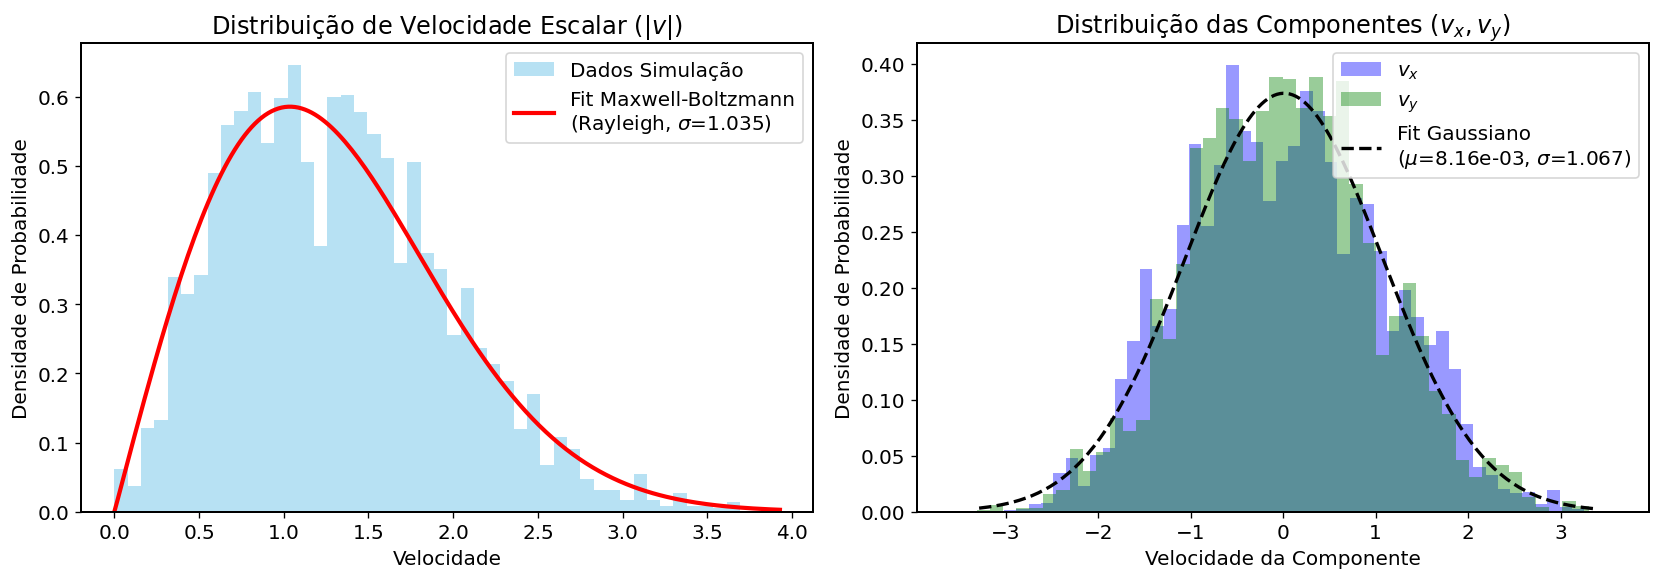

Rodando simulação com distribuição inicial uniforme...


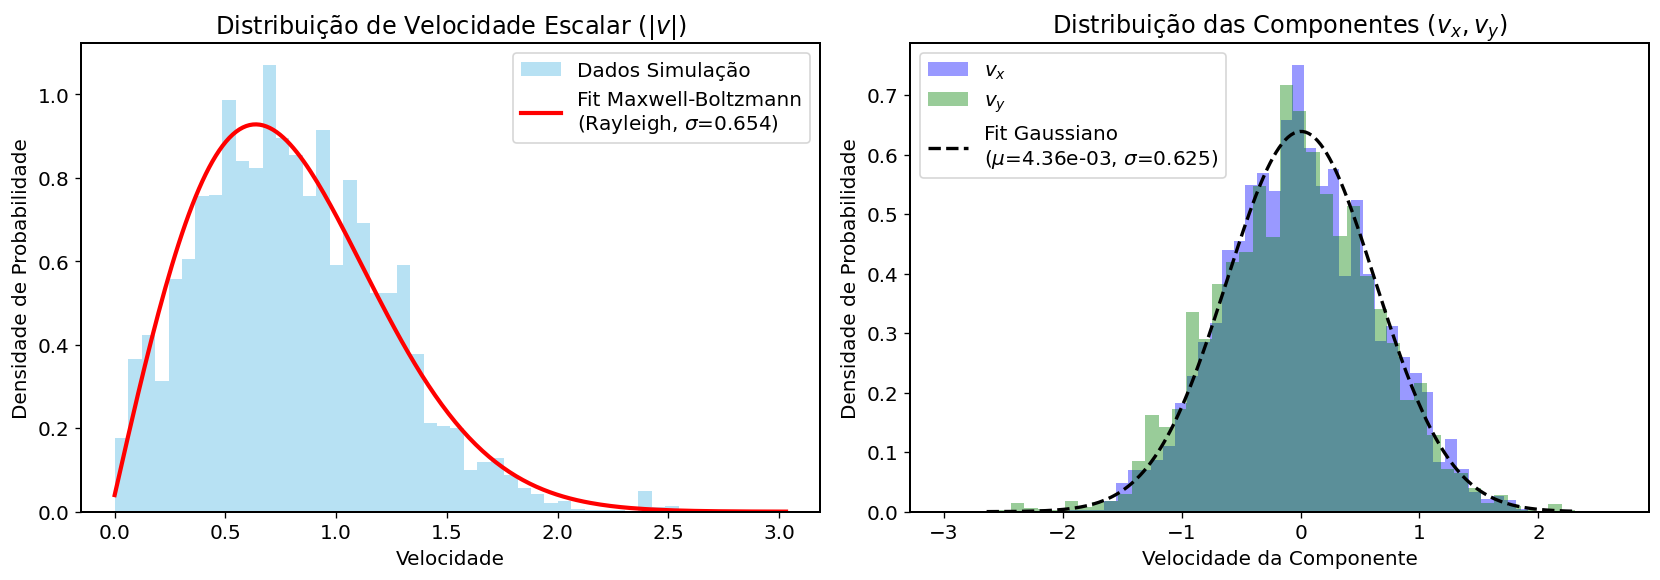

{'vx_std': np.float64(0.6245424642456954),
 'speed_scale': np.float64(0.6536236821667655)}

In [17]:
# Configuração de parâmetros para um teste estatisticamente relevante
params_teste = {
    "N": 400,
    "L": 140,
    "dt": 0.001,
    "m": 1.0,
    "epsilon": 1.0,
    "sigma": 1.0,
    "r_cut": 2.5,
    "velocity_distribution": "maxwell",
    "v0": 1.0,
    "n_steps": 100000
}


# Temperatura:
# Frio T < 0.3: v0 = 1.0
# Caso limite T ~ 1.0: v0 = 2.5
# Gás quente T ~ 3.0: v0 = 4.0

# Já iniciamos com uma distribuição de velocidades "maxwell" para garantir que o sistema comece em um estado próximo do equilíbrio.
print("Rodando simulação com distribuição inicial gaussiana...")
analyze_observables(params_teste, n_avg_steps=20000)


params_teste["velocity_distribution"] = "uniform" # Forçamos um estado inicial fora do equilíbrio

# Queremos ver se as colisões levam o sistema ao equilíbrio (Maxwell-Boltzmann)
print("Rodando simulação com distribuição inicial uniforme...")
analyze_observables(params_teste, n_avg_steps=20000)

In [22]:
base_params = {
    "N": 1000,
    "L": 80,              # ρ ≈ 0.16
    "dt": 0.002,
    "m": 1.0,
    "epsilon": 1.0,
    "sigma": 1.0,
    "r_cut": 2.5,
    "velocity_distribution": "uniform",
    "n_steps": 5000
}

v0_list = [1.0, 2.5, 4.0]
labels = ["Frio", "Intermediário", "Quente"]

trajectories = []

for v0 in v0_list:
    params = base_params.copy()
    params["v0"] = v0
    
    traj, _ = run_simulation_and_track(params)
    trajectories.append(traj)

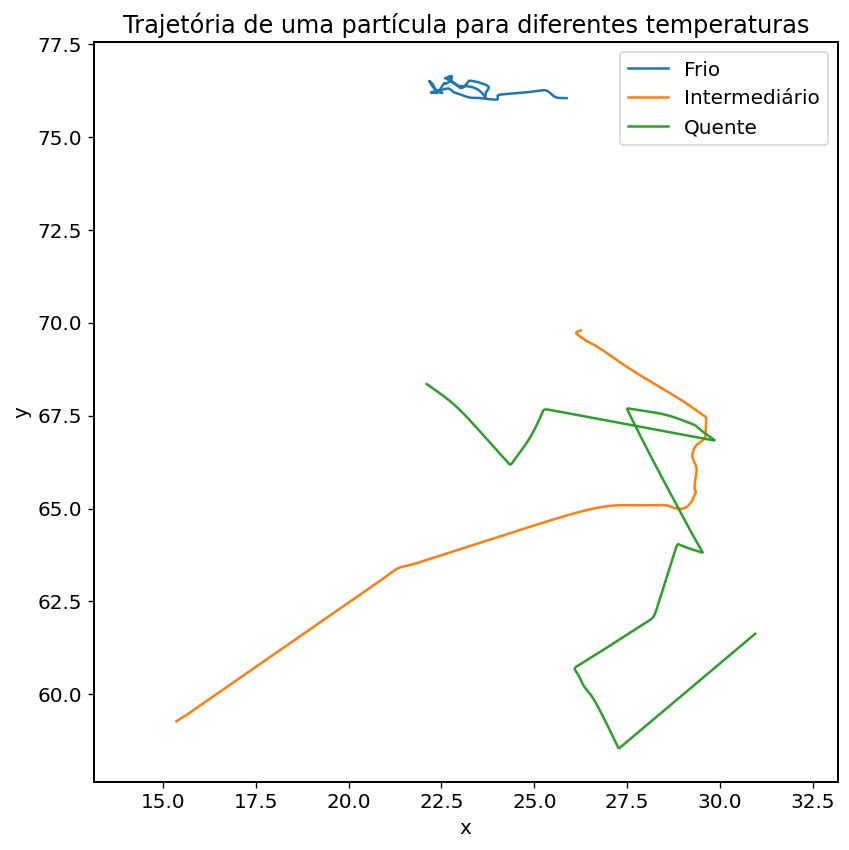

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

for traj, label in zip(trajectories, labels):
    plt.plot(traj[:,0], traj[:,1], label=label)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajetória de uma partícula para diferentes temperaturas")
plt.legend()
plt.axis("equal")
plt.show()

In [27]:
L = 60

solid_params = {
    "N": 2160,
    "L": L,
    "dt": 0.002,
    "m": 1.0,
    "epsilon": 1.0,
    "sigma": 1.0,
    "r_cut": 2.5,
    "velocity_distribution": "maxwell",
    "v0": 0.45,
    "n_steps": 15000
}

liquid_params = solid_params.copy()
liquid_params["N"] = 1080
liquid_params["v0"] = 1.0

gas_params = solid_params.copy()
gas_params["N"] = 360
gas_params["v0"] = 2.0
gas_params["dt"] = 0.001
# Como diminuimos dt, aumentamos o número de passos para manter a mesma duração total da simulação
gas_params["n_steps"] = 30000

In [28]:
traj_solid, _ = run_simulation_and_track(solid_params)
traj_liquid, _ = run_simulation_and_track(liquid_params)
traj_gas, _ = run_simulation_and_track(gas_params)

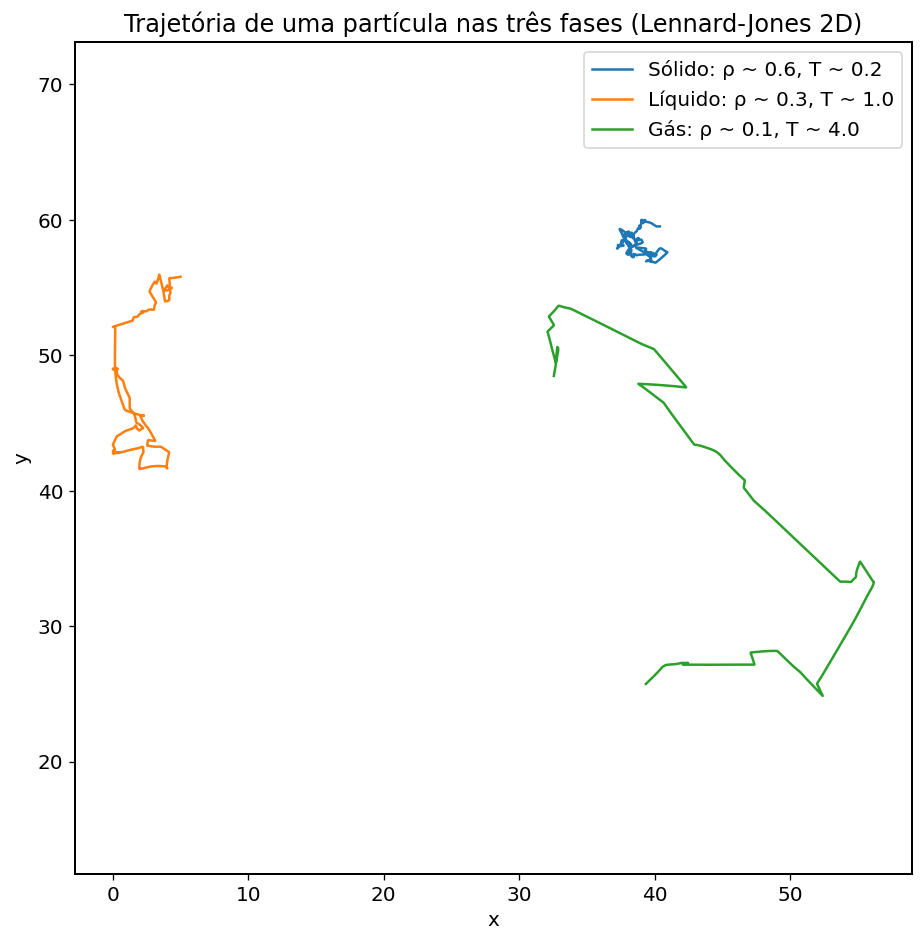

In [29]:
start = 2000

plt.figure(figsize=(9,9))

plt.plot(traj_solid[start:,0], traj_solid[start:,1], 
         label="Sólido: ρ ~ 0.6, T ~ 0.2")

plt.plot(traj_liquid[start:,0], traj_liquid[start:,1], 
         label="Líquido: ρ ~ 0.3, T ~ 1.0")

plt.plot(traj_gas[start:,0], traj_gas[start:,1], 
         label="Gás: ρ ~ 0.1, T ~ 4.0")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajetória de uma partícula nas três fases (Lennard-Jones 2D)")
plt.axis("equal")
plt.show()